# Exercise 1 - Principal Component Analysis on Real Estate Data

### Aim
Maggie is a real-estate agent and she is puzzled about why some of the properties managed by her company have not been sold for more than six months. PCA is used to reduce the property variables into a smaller number of principal components and identify the variables that contribute most to the main patterns in the properties.

For this analysis, the **USA House Sales Data** dataset is used. It contains 3,000 residential property listings and includes variables such as price, bedrooms, bathrooms, area, lot size, year built and **Days on Market**. The dataset is synthetic/mock data, so the results are used only for this exercise.

Since six months is approximately 180 days, properties with `Days on Market > 180` are treated as the properties that have taken more than six months to sell.

## 1. Import the required libraries

In [14]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Upload the dataset

The CSV file is uploaded directly to Google Colab.

In [15]:
uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print('Uploaded file:', filename)
print('Dataset shape:', df.shape)
display(df.head())

Saving us_house_Sales_data.csv to us_house_Sales_data (2).csv
Uploaded file: us_house_Sales_data (2).csv
Dataset shape: (3000, 16)


,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
0,"$554,217","5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1 bds,3 ba,772 sqft,4757 sqft,1959,101,Townhouse,Z104635,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/80374762_zpid/
1,"$164,454","9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1 bds,1 ba,2348 sqft,3615 sqft,1969,46,Apartment,Z535721,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/86143665_zpid/
2,"$1,249,331","8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6 bds,1 ba,3630 sqft,9369 sqft,1990,59,Townhouse,Z900458,Mike Lee - Coldwell Banker,For Sale,https://www.zillow.com/homedetails/37082403_zpid/
3,"$189,267","232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2 bds,1 ba,605 sqft,8804 sqft,1958,119,Apartment,Z318589,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/39318132_zpid/
4,"$465,778","5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3 bds,2 ba,1711 sqft,9260 sqft,2020,26,Townhouse,Z899716,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/22454634_zpid/


## 3. Check the dataset

The dataset contains property information as well as `Days on Market`, which is the variable needed to identify properties that have remained unsold for more than six months.

In [16]:
print('Columns in the dataset:')
print(list(df.columns))

print('\nMissing values:')
display(df.isnull().sum())

print('\nData types:')
display(df.dtypes)

Columns in the dataset:
['Price', 'Address', 'City', 'Zipcode', 'State', 'Bedrooms', 'Bathrooms', 'Area (Sqft)', 'Lot Size', 'Year Built', 'Days on Market', 'Property Type', 'MLS ID', 'Listing Agent', 'Status', 'Listing URL']

Missing values:


,0
Price,0
Address,0
City,0
Zipcode,0
State,0
Bedrooms,0
Bathrooms,0
Area (Sqft),0
Lot Size,0
Year Built,0



Data types:


,0
Price,object
Address,object
City,object
Zipcode,int64
State,object
Bedrooms,object
Bathrooms,object
Area (Sqft),object
Lot Size,object
Year Built,int64


## 4. Identify the Days on Market column

The Kaggle dataset uses `Days on Market`. The check below makes the notebook stop clearly if the uploaded file is not the expected dataset.

In [17]:
dom_column = next((col for col in df.columns if str(col).strip().lower() == 'days on market'), None)

if dom_column is None:
    raise ValueError("The uploaded dataset does not contain a 'Days on Market' column.")

df[dom_column] = pd.to_numeric(df[dom_column], errors='coerce')

print('Days on Market column:', dom_column)
print('\nDays on Market summary:')
display(df[dom_column].describe())

Days on Market column: Days on Market

Days on Market summary:


,Days on Market
count,3000.000000
mean,61.199333
std,34.890983
min,1.000000
25%,31.000000
50%,62.000000
75%,91.000000
max,120.000000


## 5. Separate the properties that have been on the market for more than six months

Six months is taken as approximately 180 days for this analysis. The long-listed group contains properties with `Days on Market > 180`.

In [18]:
six_months = 180

long_listed = df[df[dom_column] > six_months].copy()
other_properties = df[df[dom_column] <= six_months].copy()

print('Properties with Days on Market > 180:', len(long_listed))
print('Properties with Days on Market <= 180:', len(other_properties))
print('Total properties:', len(df))

print('\nPercentage taking more than six months:')
print(f'{len(long_listed) / len(df) * 100:.2f}%')

Properties with Days on Market > 180: 0
Properties with Days on Market <= 180: 3000
Total properties: 3000

Percentage taking more than six months:
0.00%


## 6. Compare the two groups

Before applying PCA, I compare the basic numerical properties of the long-listed group with the other properties. This gives an initial idea of how the two groups differ.

In [19]:
comparison_columns = [
    col for col in ['Price', 'Bedrooms', 'Bathrooms', 'Area (Sqft)', 'Lot Size', 'Year Built', 'Days on Market']
    if col in df.columns
]

comparison_table = pd.DataFrame({
    'Long-listed (>180 days)': long_listed[comparison_columns].mean(numeric_only=True),
    'Other properties (<=180 days)': other_properties[comparison_columns].mean(numeric_only=True)
})

display(comparison_table.round(2))

,Long-listed (>180 days),Other properties (<=180 days)
Year Built,NaN,1986.81
Days on Market,NaN,61.20


## 7. Select variables for PCA

PCA is performed on the numerical property characteristics. `Days on Market` is kept separate from the PCA variables because it is used to define the group that Maggie is interested in. Identifiers and location codes are also not treated as property characteristics.

In [20]:
preferred_features = [
    'Price',
    'Bedrooms',
    'Bathrooms',
    'Area (Sqft)',
    'Lot Size',
    'Year Built'
]

pca_features = [col for col in preferred_features if col in df.columns]

if len(pca_features) < 2:
    raise ValueError('Not enough expected property variables were found for PCA.')

print('Variables used for PCA:')
print(pca_features)

Variables used for PCA:
['Price', 'Bedrooms', 'Bathrooms', 'Area (Sqft)', 'Lot Size', 'Year Built']


## 8. Prepare and standardize the data

The selected variables have different units and scales. Standardization is therefore done before PCA so that a variable with a large numerical scale does not dominate the analysis.

In [21]:
## 8. Prepare and standardize the data

pca_data = df[pca_features].copy()

# Convert values to numbers
# This also removes commas, dollar signs and other non-numeric characters
for col in pca_features:
    pca_data[col] = (
        pca_data[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False)
        .str.extract(r'([-+]?\d*\.?\d+)')[0]
    )
    pca_data[col] = pd.to_numeric(pca_data[col], errors='coerce')

print('Missing values after conversion:')
display(pca_data.isnull().sum())

# Remove rows where any PCA variable is missing
valid_rows = pca_data.notna().all(axis=1)

pca_data = pca_data.loc[valid_rows].reset_index(drop=True)
analysis_df = df.loc[valid_rows].reset_index(drop=True).copy()

print('Data used for PCA:', pca_data.shape)

if len(pca_data) == 0:
    raise ValueError('No valid rows were found for PCA. Please check the uploaded CSV.')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_data)

scaled_data = pd.DataFrame(X_scaled, columns=pca_features)

display(scaled_data.head())

Missing values after conversion:


,0
Price,0
Bedrooms,0
Bathrooms,0
Area (Sqft),0
Lot Size,0
Year Built,0


Data used for PCA: (3000, 6)


,Price,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built
0,-0.642143,-1.447641,0.444304,-1.542041,-0.282338,-1.307759
1,-1.617366,-1.447641,-1.338855,0.070657,-0.716866,-0.837584
2,1.097097,1.483202,-1.338855,1.382510,1.472518,0.149782
3,-1.555282,-0.861473,-1.338855,-1.712930,1.257537,-1.354776
4,-0.863426,-0.275304,-0.447276,-0.581176,1.431044,1.560305


## 9. Covariance matrix

The covariance matrix shows how the standardized property variables vary together.

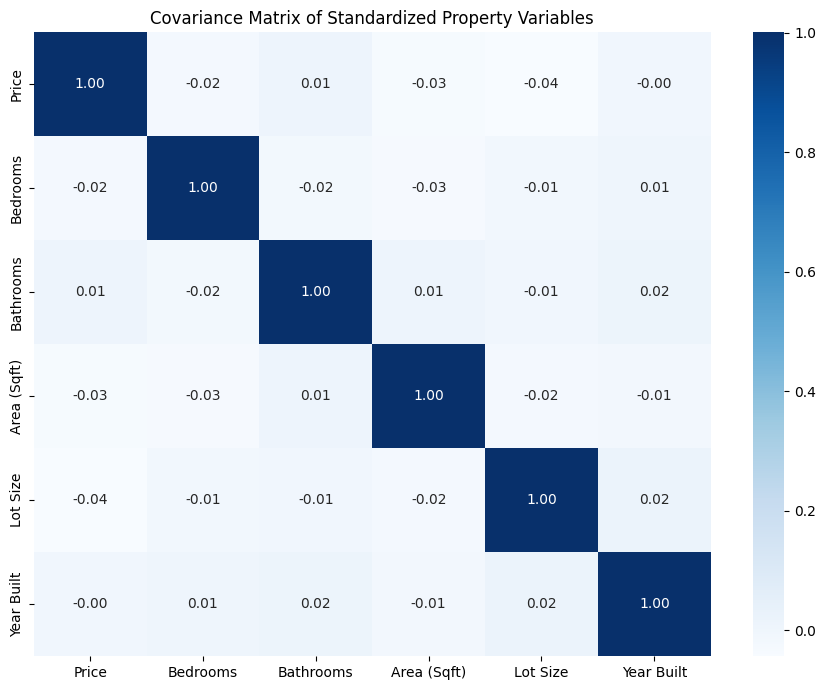

In [22]:
covariance_matrix = np.cov(X_scaled, rowvar=False)
covariance_df = pd.DataFrame(
    covariance_matrix,
    index=pca_features,
    columns=pca_features
)

plt.figure(figsize=(9, 7))
sns.heatmap(covariance_df, annot=True, fmt='.2f', cmap='Blues')
plt.title('Covariance Matrix of Standardized Property Variables')
plt.tight_layout()
plt.show()

## 10. Apply PCA

PCA is applied to the standardized property variables. The first principal component represents the direction containing the largest amount of variation in the data.

In [23]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

component_names = [f'PC{i}' for i in range(1, len(pca.components_) + 1)]
scores = pd.DataFrame(X_pca, columns=component_names)

print('Principal components:', len(component_names))
display(scores.head())

Principal components: 6


,PC1,PC2,PC3,PC4,PC5,PC6
0,-0.497333,-0.005921,-0.033275,-1.373488,1.191656,-1.821610
1,0.064896,0.998711,-1.507935,-0.927766,-0.663199,-1.774380
2,0.882085,-0.269477,-0.790682,-0.038630,-0.796306,2.680794
3,1.621426,-0.141036,-1.056553,-2.258068,0.699382,-1.396886
4,1.923457,0.144721,1.098973,-0.500360,-0.777597,-0.241176


## 11. Explained variance

The explained variance ratio shows how much of the total variation is represented by each principal component.

In [24]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_df = pd.DataFrame({
    'Principal Component': component_names,
    'Explained Variance (%)': explained_variance * 100,
    'Cumulative Variance (%)': cumulative_variance * 100
})

display(variance_df.round(3))

,Principal Component,Explained Variance (%),Cumulative Variance (%)
0,PC1,17.569,17.569
1,PC2,17.329,34.898
2,PC3,17.006,51.904
3,PC4,16.604,68.508
4,PC5,16.151,84.660
5,PC6,15.340,100.000


## 12. Scree plot

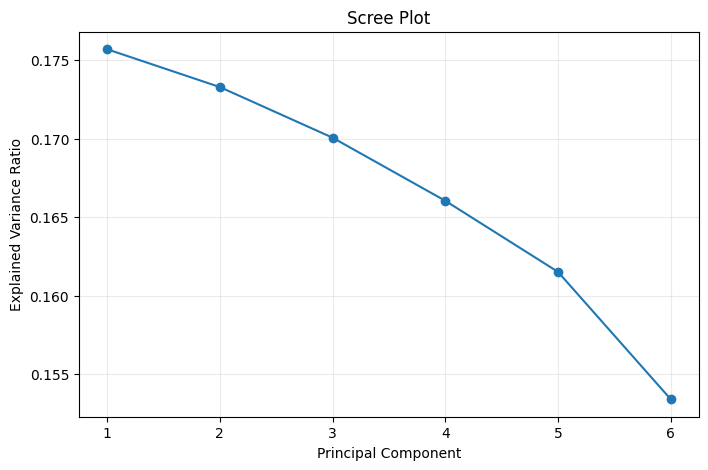

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(alpha=0.25)
plt.show()

## 13. PCA loadings

The PCA loadings show the contribution of each original property variable to each principal component.

In [26]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=component_names
)

display(loadings.round(4))

,PC1,PC2,PC3,PC4,PC5,PC6
Price,-0.5779,-0.4621,0.2352,-0.2057,-0.1212,0.5833
Bedrooms,0.3584,-0.4318,-0.2715,0.6260,0.2511,0.3955
Bathrooms,-0.2464,0.2621,0.5901,0.3359,0.6395,-0.0231
Area (Sqft),-0.1949,0.7025,-0.2359,0.2882,-0.2784,0.5023
Lot Size,0.5985,0.1819,0.2548,-0.5034,0.2033,0.4990
Year Built,0.2841,-0.0692,0.6341,0.3413,-0.6280,-0.0391


## 14. Variables contributing most to PC1

PC1 explains the largest amount of variance. I rank the variables using the absolute value of their PC1 loadings to identify the strongest contributors.

Variables ranked by absolute PC1 loading:


,PC1 Loading
Lot Size,0.5985
Price,-0.5779
Bedrooms,0.3584
Year Built,0.2841
Bathrooms,-0.2464
Area (Sqft),-0.1949


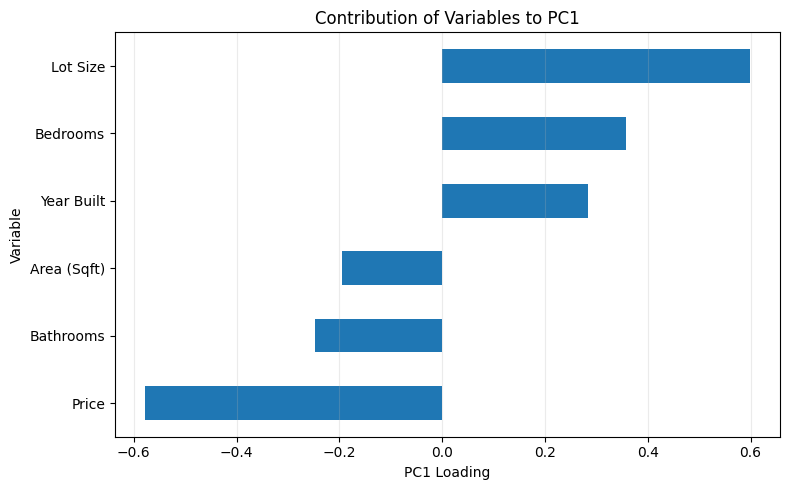

In [27]:
pc1_ranking = loadings['PC1'].sort_values(key=np.abs, ascending=False)

print('Variables ranked by absolute PC1 loading:')
display(pc1_ranking.to_frame(name='PC1 Loading').round(4))

plt.figure(figsize=(8, 5))
pc1_ranking.sort_values().plot(kind='barh')
plt.xlabel('PC1 Loading')
plt.ylabel('Variable')
plt.title('Contribution of Variables to PC1')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## 15. Compare the PCA scores of long-listed properties

The PCA scores are combined with the Days on Market value. This makes it possible to see where the properties taking more than six months to sell lie in the principal-component space.

In [28]:
scores['Days on Market'] = analysis_df[dom_column].values
scores['Long Listed'] = np.where(scores['Days on Market'] > six_months, 'More than 180 days', '180 days or less')

print('Average PCA scores by group:')
display(scores.groupby('Long Listed')[component_names[:min(3, len(component_names))]].mean().round(3))

Average PCA scores by group:


,PC1,PC2,PC3
Long Listed,,,
180 days or less,0.0,-0.0,0.0


## 16. PC1 vs PC2

The first two principal components are plotted to compare the properties that took more than six months with the remaining properties.

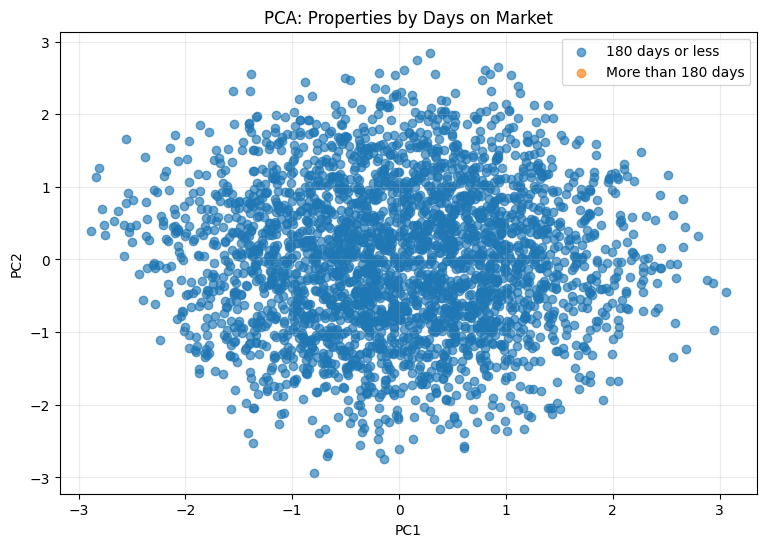

In [29]:
if len(component_names) >= 2:
    plt.figure(figsize=(9, 6))

    for group in ['180 days or less', 'More than 180 days']:
        subset = scores[scores['Long Listed'] == group]
        plt.scatter(subset['PC1'], subset['PC2'], alpha=0.65, label=group)

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA: Properties by Days on Market')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

## 17. Relationship between Days on Market and the main property variables

As an additional check, I calculate correlations between Days on Market and the property variables used in the PCA. This is not part of PCA itself, but it helps connect the PCA findings back to Maggie's question.

In [30]:
correlation_data = analysis_df[pca_features + [dom_column]].copy()
correlation_data = correlation_data.apply(pd.to_numeric, errors='coerce')

dom_correlations = correlation_data.corr()[dom_column].drop(dom_column).sort_values(key=np.abs, ascending=False)

print('Correlation with Days on Market:')
display(dom_correlations.to_frame(name='Correlation').round(4))

Correlation with Days on Market:


,Correlation
Year Built,-0.0133
Price,NaN
Bedrooms,NaN
Bathrooms,NaN
Area (Sqft),NaN
Lot Size,NaN


## 18. Components needed to explain most of the variance

This gives an additional summary of how many components are required to represent at least 80% and 90% of the variation in the selected property variables.

In [31]:
components_80 = np.argmax(cumulative_variance >= 0.80) + 1
components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print('Components needed for at least 80% variance:', components_80)
print('Components needed for at least 90% variance:', components_90)

Components needed for at least 80% variance: 5
Components needed for at least 90% variance: 6


## 19. Conclusion

PCA was applied to the main numerical property characteristics after standardizing them. The properties that remained on the market for more than 180 days were then compared with the other properties in terms of the principal-component scores.

The variables with the largest absolute loadings on PC1 are the strongest contributors to the main pattern in the property data. These variables, together with the comparison of the long-listed group and the correlation with Days on Market, provide useful insights into the characteristics associated with properties taking more than six months to sell.

PCA and correlation show associations in the dataset. They do not by themselves prove that one property characteristic causes a property to remain unsold.